In [1]:
"""
Autoencoders no se usan apenas para compresión.

Tres usos reales de autoencoders en PyTorch
═══════════════════════════════════════════
  1. Detección de anomalías  → Breast Cancer Wisconsin (sklearn)
  2. Denoising               → Digits dataset con ruido gaussiano
  3. VAE generativo          → Digits dataset, generar e interpolar

Todos los datasets están en sklearn, sin descargas externas.
"""

'\nAutoencoders no se usan apenas para compresión.\n\nTres usos reales de autoencoders en PyTorch\n═══════════════════════════════════════════\n  1. Detección de anomalías  → Breast Cancer Wisconsin (sklearn)\n  2. Denoising               → Digits dataset con ruido gaussiano\n  3. VAE generativo          → Digits dataset, generar e interpolar\n\nTodos los datasets están en sklearn, sin descargas externas.\n'

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {DEVICE}\n")


Usando: cpu



In [3]:
# ══════════════════════════════════════════════════════════════════════
# 1. DETECCIÓN DE ANOMALÍAS
#    Dataset: Breast Cancer Wisconsin (30 features numéricas)
#    Idea: entrenamos SOLO con ejemplos benignos. En producción,
#    un error de reconstrucción alto indica un tumor maligno (anomalía).
#    La utilidad, es que no necesitamos ejemplos de anomalías para entrenar, que suelen ser escasos.
# ══════════════════════════════════════════════════════════════════════
print("═" * 60)
print("1. DETECCIÓN DE ANOMALÍAS — Breast Cancer Wisconsin")
print("═" * 60)

bc   = load_breast_cancer()
X, y = bc.data.astype(np.float32), bc.target  # 1=benigno, 0=maligno

X_normal = X[y == 1]   # 357 benignos → usados para entrenar
X_anom   = X[y == 0]   # 212 malignos → los "detectamos" en eval

scaler           = StandardScaler()
X_normal_scaled  = scaler.fit_transform(X_normal).astype(np.float32)
X_anom_scaled    = scaler.transform(X_anom).astype(np.float32)

# Split train/val dentro de los normales
X_tr, X_val = train_test_split(X_normal_scaled, test_size=0.2, random_state=42)

train_dl = DataLoader(TensorDataset(torch.tensor(X_tr)),  batch_size=64, shuffle=True)
val_dl   = DataLoader(TensorDataset(torch.tensor(X_val)), batch_size=64)

print(f"Benignos train: {len(X_tr)}  | Benignos val: {len(X_val)}  |  Malignos eval: {len(X_anom_scaled)}")

════════════════════════════════════════════════════════════
1. DETECCIÓN DE ANOMALÍAS — Breast Cancer Wisconsin
════════════════════════════════════════════════════════════
Benignos train: 285  | Benignos val: 72  |  Malignos eval: 212


In [4]:
import pandas as pd
pd.DataFrame(bc.data, columns=bc.feature_names)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
class AnomalyAE(nn.Module):
    def __init__(self, in_dim, latent=8):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, 32), nn.ReLU(),
            nn.Linear(32, latent)
        )
        self.dec = nn.Sequential(
            nn.Linear(latent, 32), nn.ReLU(),
            nn.Linear(32, in_dim)
        )
    def forward(self, x):
        return self.dec(self.enc(x))
    def recon_error(self, x):
        return F.mse_loss(self(x), x, reduction="none").mean(dim=1)


Threshold (p95): 1.1557
Recall  (malignos detectados): 74.5%
FPR     (benignos mal clasif): 5.6%


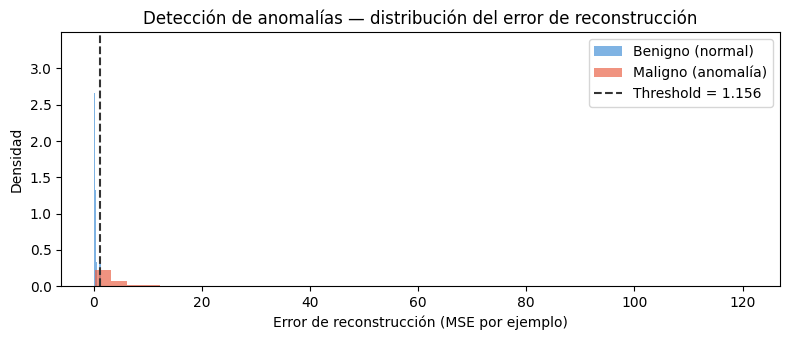

In [6]:
model_ae = AnomalyAE(X_tr.shape[1]).to(DEVICE)
opt_ae   = torch.optim.Adam(model_ae.parameters(), lr=1e-3)

for epoch in range(1, 21):
    model_ae.train()
    for (xb,) in train_dl:
        xb   = xb.to(DEVICE)
        loss = F.mse_loss(model_ae(xb), xb)
        opt_ae.zero_grad(); loss.backward(); opt_ae.step()

model_ae.eval()
with torch.no_grad():
    err_normal = model_ae.recon_error(torch.tensor(X_val).to(DEVICE)).cpu().numpy()
    err_anom   = model_ae.recon_error(torch.tensor(X_anom_scaled).to(DEVICE)).cpu().numpy()

threshold = np.percentile(err_normal, 95)  # umbral al 95% de error de reconstrucción de los benignos, para detectar anomalías
recall    = (err_anom   > threshold).mean() # porcentaje de malignos reales que superan el umbral (malignos detectados)
fpr       = (err_normal > threshold).mean() # porcentaje de benignos que superan el umbral (falsos positivos)
print(f"Threshold (p95): {threshold:.4f}")
print(f"Recall  (malignos detectados): {recall:.1%}")
print(f"FPR     (benignos mal clasif): {fpr:.1%}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(err_normal, bins=40, alpha=0.65, color="#3B8BD4", density=True, label="Benigno (normal)")
ax.hist(err_anom,   bins=40, alpha=0.65, color="#E8593C", density=True, label="Maligno (anomalía)")
ax.axvline(threshold, color="#333", ls="--", lw=1.5, label=f"Threshold = {threshold:.3f}")
ax.set_xlabel("Error de reconstrucción (MSE por ejemplo)")
ax.set_ylabel("Densidad")
ax.set_title("Detección de anomalías — distribución del error de reconstrucción")
ax.legend()
plt.tight_layout()
plt.show()

════════════════════════════════════════════════════════════
2. DENOISING — Digits 8×8 con ruido gaussiano
════════════════════════════════════════════════════════════


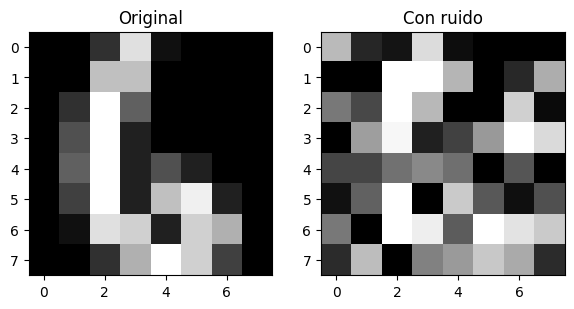

In [7]:
# ══════════════════════════════════════════════════════════════════════
# 2. DENOISING AUTOENCODER
#    Dataset: Digits (sklearn) — imágenes 8×8 de dígitos escritos a mano
#    Idea: input = imagen con ruido gaussiano | target = imagen limpia
#    El modelo aprende a "limpiar" la señal
# ══════════════════════════════════════════════════════════════════════
print("═" * 60)
print("2. DENOISING — Digits 8×8 con ruido gaussiano")
print("═" * 60)

digits          = load_digits()
X_d             = (digits.data / 16.0).astype(np.float32)   # normalizar a [0,1]
X_tr_d, X_te_d  = train_test_split(X_d, test_size=0.2, random_state=42)

train_dl_d = DataLoader(TensorDataset(torch.tensor(X_tr_d)), batch_size=128, shuffle=True)

def add_noise(x, factor=0.4):
    return torch.clamp(x + factor * torch.randn_like(x), 0., 1.)

# plot un digito con y sin ruido
idx = 0
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(X_tr_d[idx].reshape(8, 8), cmap="gray")
ax[0].set_title("Original")
ax[1].imshow(add_noise(torch.tensor(X_tr_d[idx])).reshape(8, 8), cmap="gray")
ax[1].set_title("Con ruido")
plt.tight_layout()
plt.show()

In [8]:
class DenoisingAE(nn.Module):
    def __init__(self, dim=64, latent=24):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(dim, 48), nn.ReLU(),
            nn.Linear(48, latent), nn.ReLU()
        )
        self.dec = nn.Sequential(
            nn.Linear(latent, 48), nn.ReLU(),
            nn.Linear(48, dim),    nn.Sigmoid()
        )
    def forward(self, x):
        return self.dec(self.enc(x))

  Época 10  loss: 0.07318
  Época 20  loss: 0.05871
  Época 30  loss: 0.04892


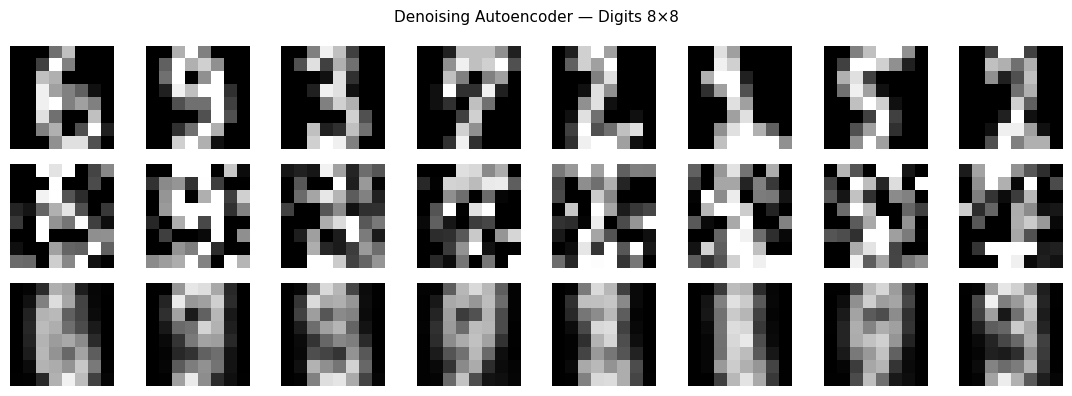

In [9]:
model_dn = DenoisingAE().to(DEVICE)
opt_dn   = torch.optim.Adam(model_dn.parameters(), lr=1e-3)

for epoch in range(1, 31):
    model_dn.train()
    total = 0
    for (xb,) in train_dl_d:
        xb       = xb.to(DEVICE)
        xb_noisy = add_noise(xb)
        loss     = F.mse_loss(model_dn(xb_noisy), xb)   
        # target = limpia, también se puede hacer con dos datasets con ruido, si el ruido es diferente entre ambos
        opt_dn.zero_grad(); loss.backward(); opt_dn.step()
        total += loss.item()
    if epoch % 10 == 0:
        print(f"  Época {epoch:2d}  loss: {total/len(train_dl_d):.5f}")

model_dn.eval()
xb_test  = torch.tensor(X_te_d[:8]).to(DEVICE)
xb_noisy = add_noise(xb_test)
with torch.no_grad():
    xb_clean = model_dn(xb_noisy)

fig, axes = plt.subplots(3, 8, figsize=(11, 4))
for col in range(8):
    for row, (data, title) in enumerate([
        (xb_test,  "Original"),
        (xb_noisy, "Con ruido"),
        (xb_clean, "Reconstruida")
    ]):
        axes[row, col].imshow(data[col].cpu().numpy().reshape(8, 8), cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, 0].set_ylabel(title, fontsize=9)

plt.suptitle("Denoising Autoencoder — Digits 8×8", fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
# ══════════════════════════════════════════════════════════════════════
# 3. VAE — VARIATIONAL AUTOENCODER
#    Dataset: Digits (sklearn)
#    Idea: el espacio latente es una distribución N(μ, σ²), no un vector fijo.
#    Podemos: (a) generar dígitos nuevos sampleando z ~ N(0,1)
#             (b) interpolar entre dos dígitos de forma continua
# ══════════════════════════════════════════════════════════════════════
print("═" * 60)
print("3. VAE GENERATIVO — Digits 8×8")
print("═" * 60)

X_tr_v, X_te_v, y_tr_v, y_te_v = train_test_split(
    X_d, digits.target, test_size=0.2, random_state=42
)
train_dl_v = DataLoader(TensorDataset(torch.tensor(X_tr_v)), batch_size=128, shuffle=True)

LATENT = 6 # espacio latente pequeño para forzar a aprender representaciones útiles

════════════════════════════════════════════════════════════
3. VAE GENERATIVO — Digits 8×8
════════════════════════════════════════════════════════════


Un Autoencoder normal toma una imagen (o dato), la comprime en un punto fijo (vector) y luego intenta reconstruirla. El problema es que ese "espacio comprimido" suele estar muy desordenado.

El VAE hace algo distinto: en lugar de comprimir la entrada en un punto, la comprime en una distribución de probabilidad (una campana de Gauss). Esto obliga al modelo a aprender un espacio latente continuo y ordenado, lo que te permite generar datos nuevos y realistas simplemente "mureando" de ese espacio.

In [12]:
class VAE(nn.Module):
    def __init__(self, dim=64, latent=LATENT):
        super().__init__()
        self.enc_shared = nn.Sequential(nn.Linear(dim, 48), nn.ReLU())
        self.fc_mu      = nn.Linear(48, latent) # μ: media de la distribución latente
        self.fc_lv      = nn.Linear(48, latent) # log(σ²): log-varianza de la distribución latente, para garantizar que σ² > 0

        self.dec        = nn.Sequential( # for decoding
            nn.Linear(latent, 48), nn.ReLU(),
            nn.Linear(48, dim),    nn.Sigmoid()
        )

    def encode(self, x):
        h  = self.enc_shared(x)
        return self.fc_mu(h), self.fc_lv(h)

    def reparameterize(self, mu, lv):
        # z = mu + eps * sigma   (eps ~ N(0,1))
        # sigma = exp(0.5 * lv) porque lv = log(σ²) → σ² = exp(lv) → σ = exp(0.5 * lv)
        # la formula de z viene de que si z ~ N(μ, σ²), entonces cualquier punto de la distribucion
        # se puede representar como z = μ + σ * ε, con ε ~ N(0,1)
        
        # Si solo muestrearamos un numero de la distribucion latente, no podríamos backpropagar el error a través del sampleo, 
        # porque el proceso de samplear es estocástico e introduce ruido que no depende de los parámetros del modelo. El truco 
        # de reparametrización nos permite expresar el sampleo de z como una función determinista de μ, σ y un ruido ε que es 
        # independiente de los parámetros del modelo. De esta forma, podemos backpropagar el error a través de μ y σ, ya que z 
        # ahora es una función diferenciable de estos parámetros.
        return mu + torch.exp(0.5 * lv) * torch.randn_like(mu)

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, lv = self.encode(x)
        z      = self.reparameterize(mu, lv)
        return self.decode(z), mu, lv

In [ ]:
def vae_loss(xhat, x, mu, lv):
    # Reconstrucción + KL divergence
    # KL fuerza que el espacio latente sea continuo y estructurado
    recon = F.binary_cross_entropy(xhat, x, reduction="sum") # error de reconstrucción, se puede usar MSE pero BCE suele funcionar mejor con imágenes normalizadas a [0,1]
    # el error de reconstruction mira que tan parecida es la salida a la entrada, mientras que el KL fuerza que la distribución latente se parezca a una N(0,1), lo que hace 
    # que el espacio latente sea más estructurado y continuo, permitiendo generar nuevos dígitos al samplear z ~ N(0,1) y hacer interpolaciones suaves entre dígitos.
    kl    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())
    # sin kl el modelo podría aprender a usar solo una parte del espacio latente, o a mapear cada dígito a un punto específico del espacio latente, lo que dificultaría 
    # la generación de nuevos dígitos y la interpolación entre ellos.
    return recon + kl

model_vae = VAE().to(DEVICE)
opt_vae   = torch.optim.Adam(model_vae.parameters(), lr=1e-3)

for epoch in range(1, 51):
    model_vae.train()
    total = 0
    for (xb,) in train_dl_v:
        xb = xb.to(DEVICE)
        xhat, mu, lv = model_vae(xb)
        loss = vae_loss(xhat, xb, mu, lv)
        opt_vae.zero_grad(); loss.backward(); opt_vae.step()
        total += loss.item()
    if epoch % 10 == 0:
        print(f"  Época {epoch:2d}  loss: {total/len(X_tr_v):.2f}")

  Época 10  loss: 29.93
  Época 20  loss: 27.40
  Época 30  loss: 26.21
  Época 40  loss: 25.61
  Época 50  loss: 25.26


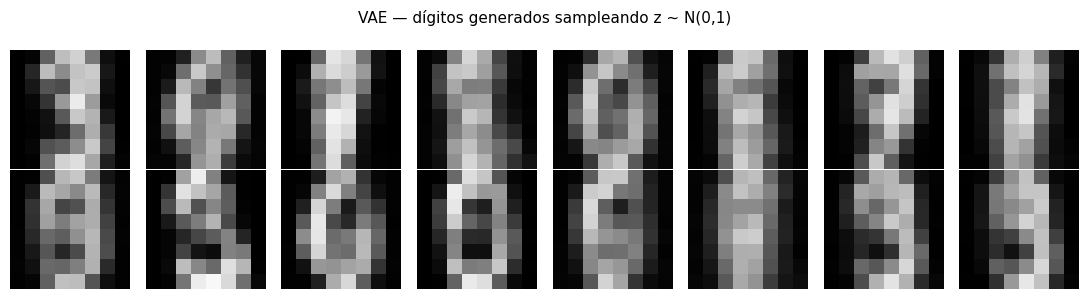

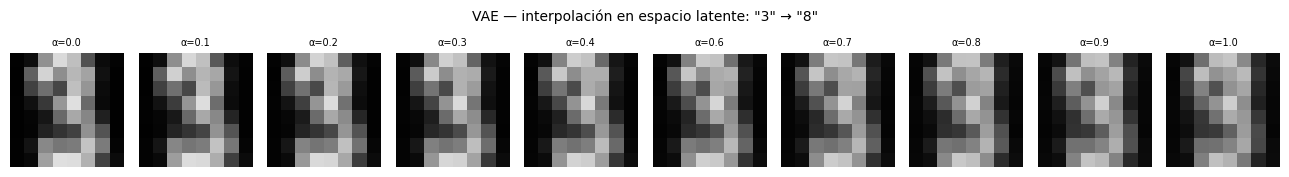

In [18]:
model_vae.eval()

# ── 3a: generar dígitos sampleando z ~ N(0,1) ──
with torch.no_grad():
    z_rand  = torch.randn(16, LATENT).to(DEVICE)
    gen     = model_vae.decode(z_rand).cpu().numpy()
    # no podemos saber el label porque es un modelo no supervisado, pero al ser un espacio latente estructurado, 
    # los dígitos generados deberían ser similares a los del dataset, aunque no sean exactamente iguales a ninguno de ellos.

fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(gen[i].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle("VAE — dígitos generados sampleando z ~ N(0,1)", fontsize=11)
plt.tight_layout()
plt.show()

# ── 3b: interpolación entre un "3" y un "8" ──
X_te_t  = torch.tensor(X_te_v)
idx_a   = np.where(y_te_v == 3)[0][0]
idx_b   = np.where(y_te_v == 8)[0][0]
xa      = X_te_t[idx_a:idx_a+1].to(DEVICE)
xb_     = X_te_t[idx_b:idx_b+1].to(DEVICE)

with torch.no_grad():
    mu_a, _ = model_vae.encode(xa)
    mu_b, _ = model_vae.encode(xb_)
    alphas  = torch.linspace(0, 1, 10).to(DEVICE)
    interps = [model_vae.decode((1-a)*mu_a + a*mu_b).cpu().numpy() for a in alphas]

fig, axes = plt.subplots(1, 10, figsize=(13, 1.8))
for i, (ax, img) in enumerate(zip(axes, interps)):
    ax.imshow(img.reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(f"α={alphas[i].item():.1f}", fontsize=7)
plt.suptitle('VAE — interpolación en espacio latente: "3" → "8"', fontsize=10)
plt.tight_layout()
plt.show()
